In [3]:
import bambi as bmb
import polars as pl
import numpy as np
import pandas as pd
import arviz as az
import matplotlib.pyplot as plt
from pingouin import circ_r
from scipy.stats import circmean, circstd, circvar
plt.style.use("arviz-docgrid")


df_nuc = pl.read_parquet(r"C:\Users\hessm\Documents\Programming\Python\scikit-ccp\sklccp\nuc_preprocessed_with_ccp_palantir.parquet")
ccp_col = "NormalizedCCP"
df_agg = (
    df_nuc.group_by("roi", maintain_order=True).agg(
        [
            pl.col(ccp_col).map_elements(circmean).alias("CcpMean"),
            pl.col(ccp_col).map_elements(circstd).alias("CcpStd"),
            pl.col(ccp_col).map_elements(circvar).alias("CcpVar"),
            pl.col(ccp_col).map_elements(circ_r).alias("CcpR"),
            pl.col("log2_nucleiRaw3_Count").mean(),
            pl.col("cycle").mean(),
        ]
    )
    # .with_columns(pl.col('nuc_count').log(2).prefix('log2_'))
)
df_agg
# df_agg = pl.read_parquet(r'C:\Users\hessm\Documents\Programming\Python\scikit-ccp\sklccp\global_synchrony4.parquet')

roi,CcpMean,CcpStd,CcpVar,CcpR,log2_nucleiRaw3_Count,cycle
str,f64,f64,f64,f64,f32,f64
"""B05_px-2211_py…",4.155636,0.566301,0.148153,0.851847,7.0,7.0
"""C06_px-2276_py…",4.337228,0.404717,0.078634,0.921366,6.988691,7.0
"""D03_px-2069_py…",5.628235,0.336006,0.054886,0.945114,6.97729,7.0
"""E04_px-1823_py…",4.956184,0.4543,0.098048,0.901952,7.0,7.0
"""E06_px-1759_py…",3.614712,0.709626,0.222588,0.777412,6.768187,7.0
"""G05_px-1287_py…",4.017975,0.479156,0.108451,0.891549,6.55459,7.0
"""B02_px+0198_py…",2.457448,0.488641,0.112534,0.887466,7.924805,8.0
"""B02_px-1488_py…",0.480581,0.608193,0.168854,0.831146,7.839224,8.0
"""B06_px-1914_py…",3.58189,0.506646,0.12045,0.87955,7.851769,8.0


In [4]:
from scipy.special import logit, expit


model = bmb.Model("logit(CcpR) ~ log2_nucleiRaw3_Count", data=df_agg.to_pandas())
idata = model.fit(draws=2000)

Auto-assigning NUTS sampler...
Initializing NUTS using jitter+adapt_diag...
Multiprocess sampling (4 chains in 4 jobs)
NUTS: [logit(CcpR)_sigma, Intercept, log2_nucleiRaw3_Count]


Sampling 4 chains for 1_000 tune and 2_000 draw iterations (4_000 + 8_000 draws total) took 36 seconds.


C:\Users\hessm\AppData\Local\Temp\ipykernel_4400\2381297636.py:2: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


                        mean     sd  hdi_3%  hdi_97%  mcse_mean  mcse_sd  \
Intercept              8.729  0.390   8.001    9.473      0.003    0.002   
log2_nucleiRaw3_Count -0.876  0.037  -0.948   -0.807      0.000    0.000   
logit(CcpR)_sigma      0.795  0.041   0.717    0.870      0.000    0.000   

                       ess_bulk  ess_tail  r_hat  
Intercept               13369.0    6706.0    1.0  
log2_nucleiRaw3_Count   13406.0    6626.0    1.0  
logit(CcpR)_sigma       12318.0    5609.0    1.0  


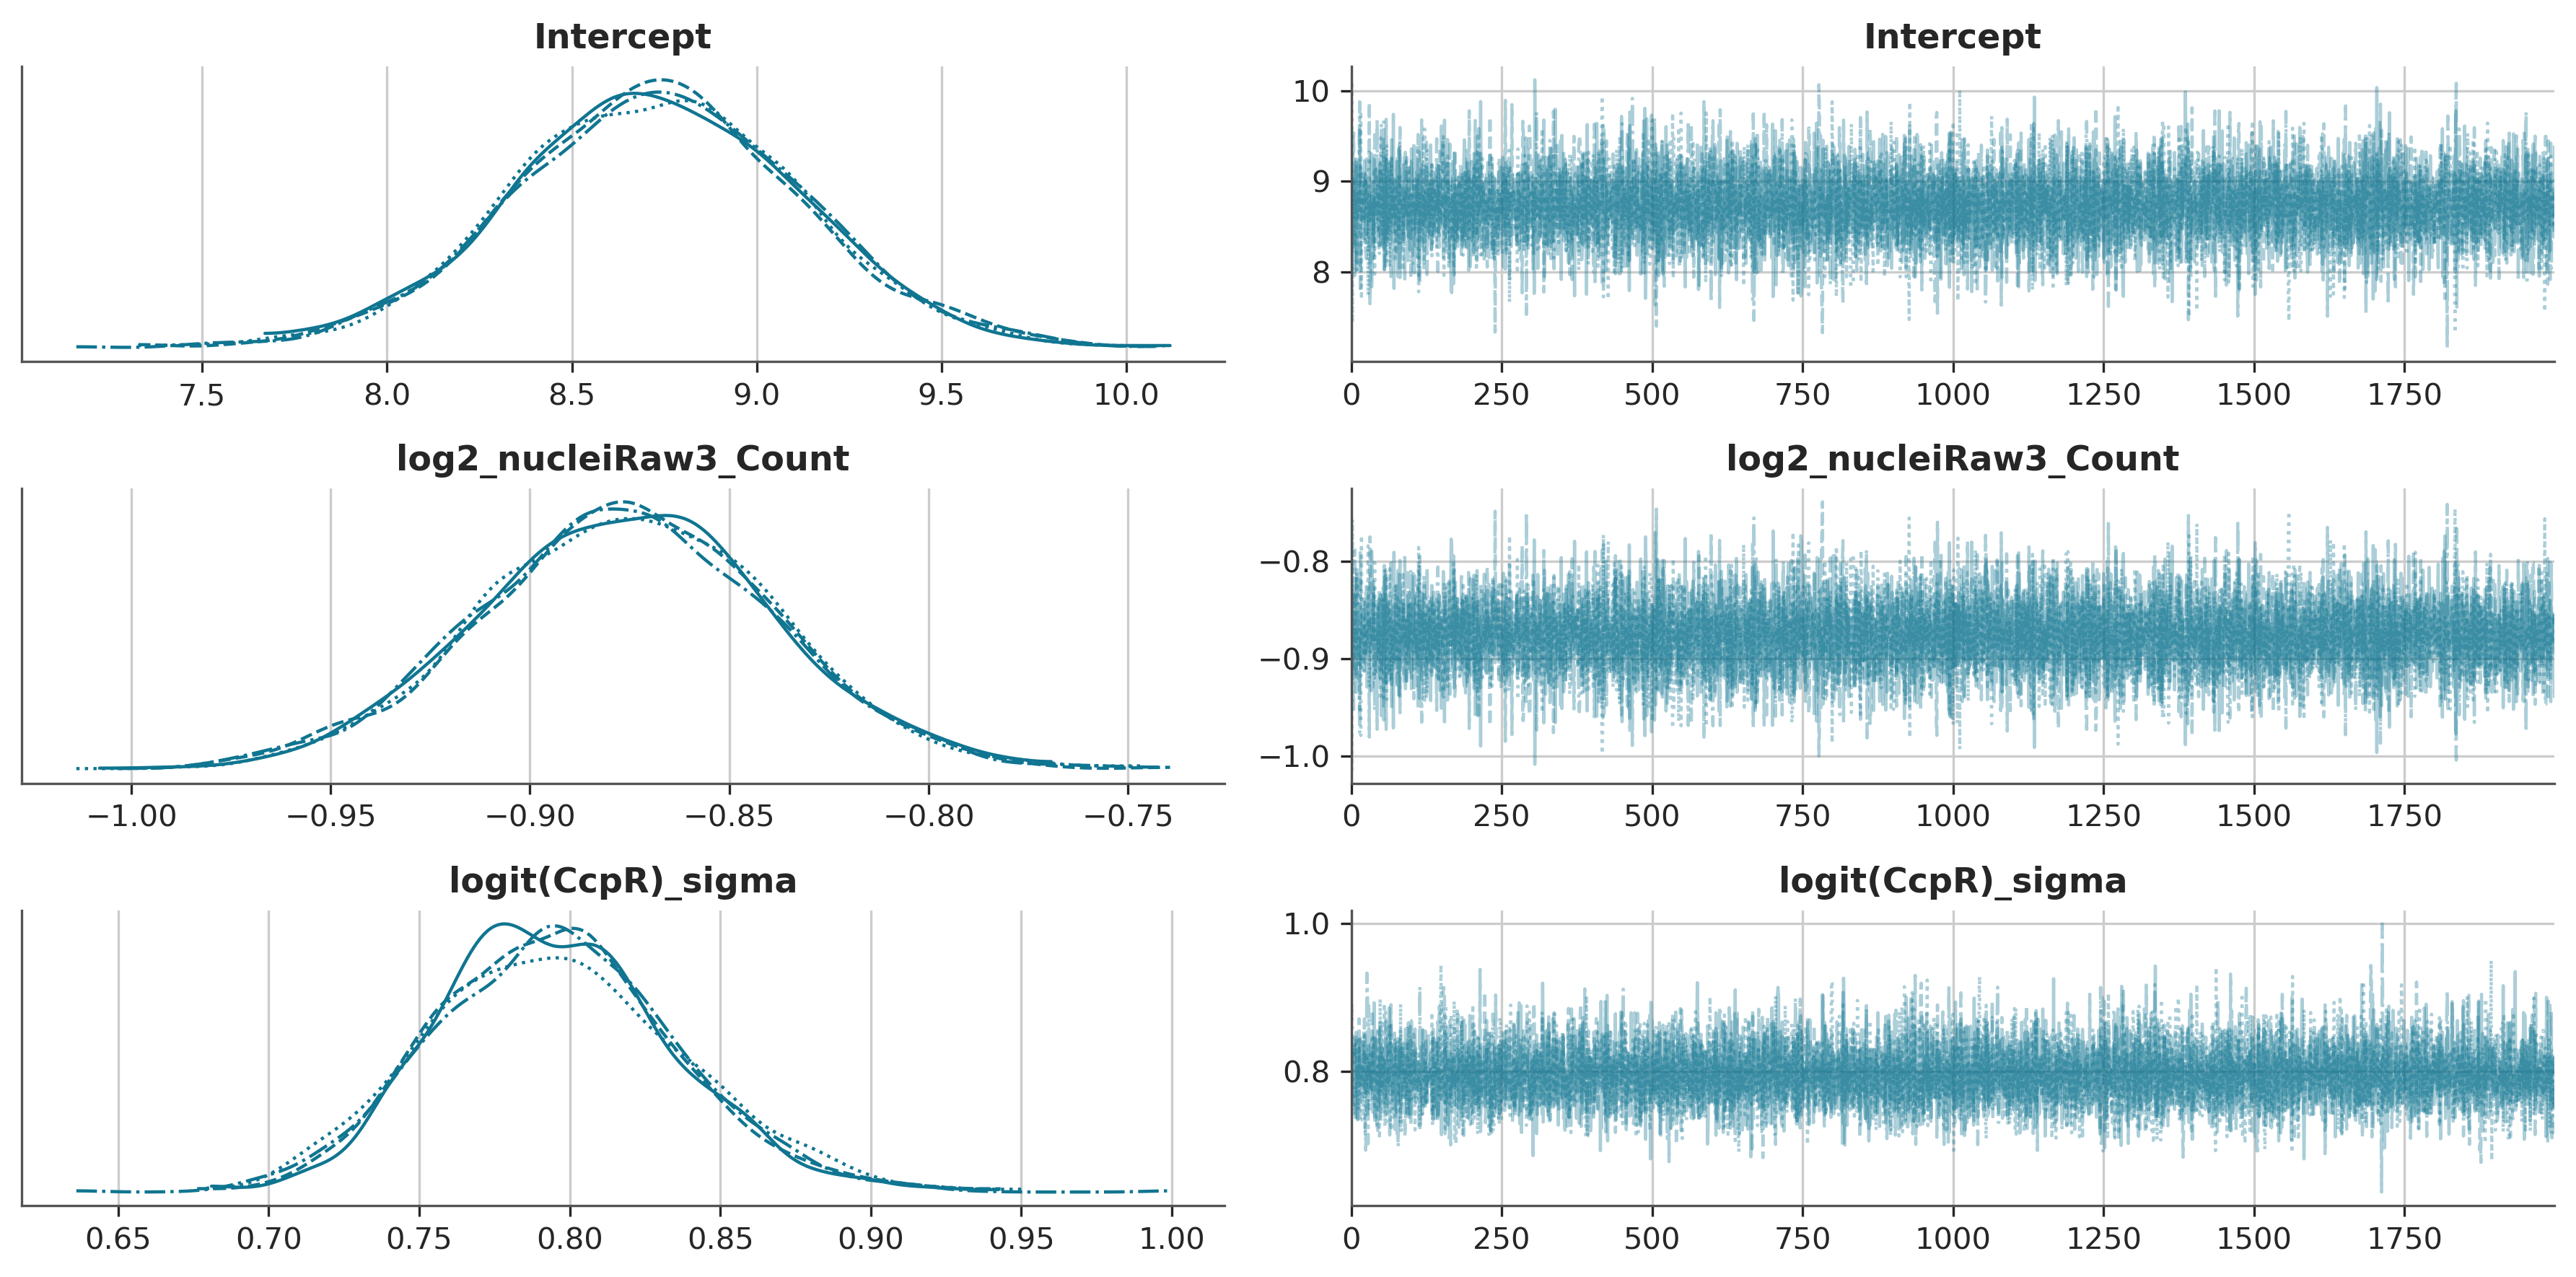

In [5]:
az.plot_trace(idata)
plt.tight_layout()
print(az.summary(idata))

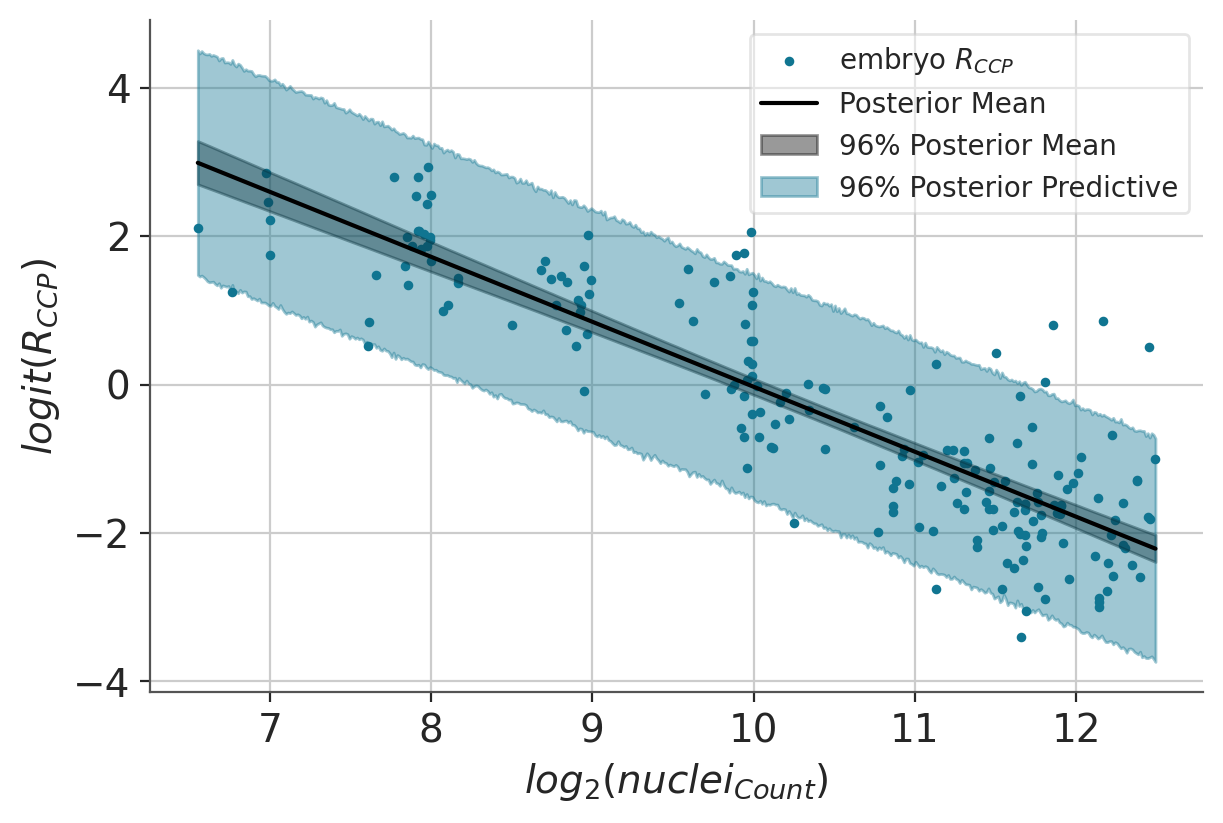

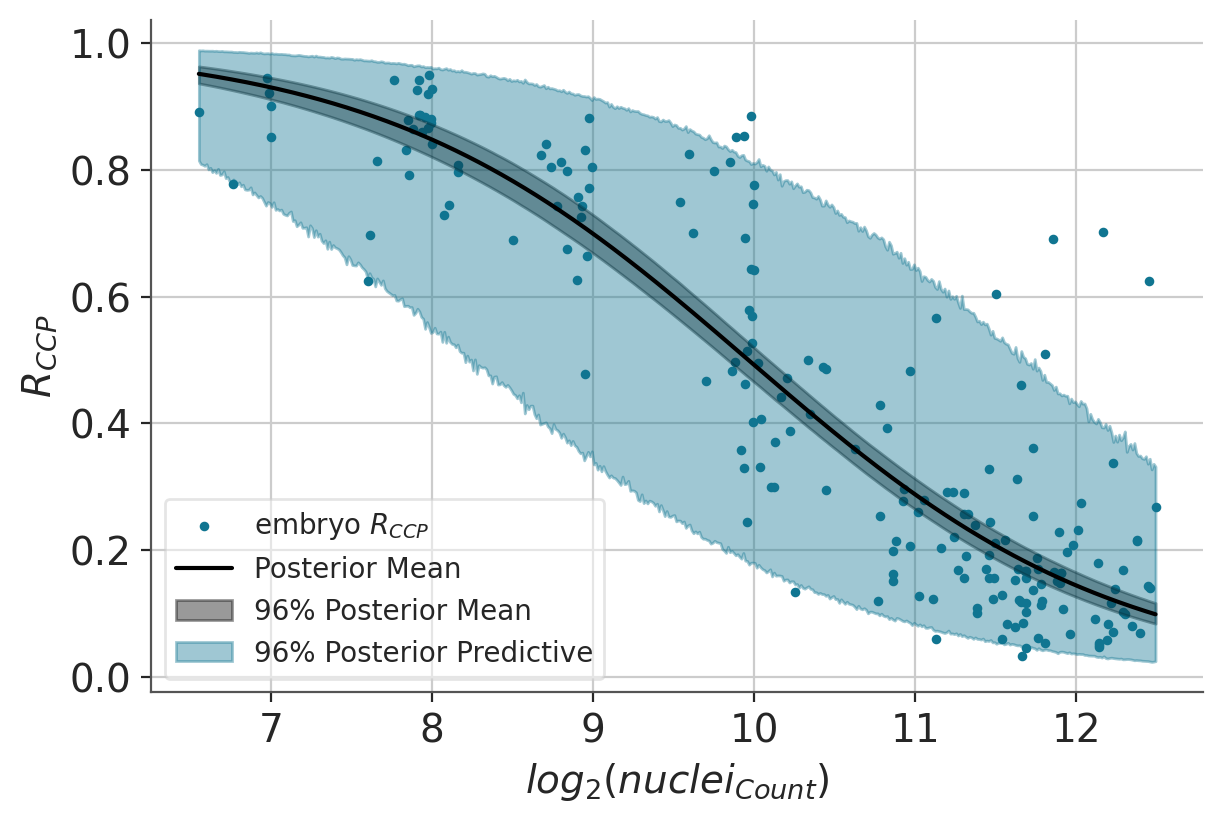

In [7]:
x_name = 'log2_nucleiRaw3_Count'
color_model = "k"
color_data = "C0"


data_range = pd.DataFrame({x_name: np.linspace(df_agg[x_name].min(), df_agg[x_name].max(), 500)})


def identity(x):
    return x

def plot_scatter(df, x='log2_nucleiRaw3_Count', y='CcpR', y_transform=identity, ax=None, color="C0", **scatter_kwargs):
    if ax is None:
        ax = plt.gca()
    ax.scatter(x=df[x], y=y_transform(df[y]), color=color, **scatter_kwargs, label='embryo $R_{CCP}$')
    return ax


def plot_pps_hdi(model, idata, ax=None, color="C0", y_transform=identity):
    if ax is None:
        ax = plt.gca()
        
    model.predict(idata, data=data_range, kind='pps')
    posterior_predictive = az.extract(idata, 'posterior_predictive')
    hdi_pps = posterior_predictive['logit(CcpR)'].quantile([0.03, 0.97], dim='sample')
    ax.fill_between(x=data_range[x_name], y1=y_transform(hdi_pps[0]), y2=y_transform(hdi_pps[1]), alpha=0.4, color=color, label='96% Posterior Predictive')

def plot_model_mean_and_hdi(model, idata, ax=None, color="k", y_transform=identity):
    if ax is None:
        ax = plt.gca()
        
    model.predict(idata, data=data_range, kind='mean')
    posterior =  az.extract(idata, group='posterior')
    y_hat = posterior['logit(CcpR)_mean']
    y_hat_mean = y_hat.mean("sample")
    y_hat_hdi = np.quantile(y_hat, [0.03, 0.97], axis=1)
    
    ax.plot(data_range[x_name].values, y_transform(y_hat_mean), color=color, label='Posterior Mean')
    ax.fill_between(data_range[x_name], y1=y_transform(y_hat_hdi[0]), y2=y_transform(y_hat_hdi[1]), alpha=0.4, color=color, label='96% Posterior Mean')



fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

plot_scatter(df_agg, y_transform=logit, s=6)
plot_model_mean_and_hdi(model, idata)
plot_pps_hdi(model, idata, color="C0")
plt.xlabel('$log_2(nuclei_{Count})$')
plt.ylabel('$logit(R_{CCP})$')
plt.legend(fancybox=True, frameon=True, fontsize='medium')

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

plot_scatter(df_agg, s=6, y_transform=identity)
plot_model_mean_and_hdi(model, idata, y_transform=expit)
plot_pps_hdi(model, idata, color="C0", y_transform=expit)
plt.xlabel('$log_2(nuclei_{Count})$')
plt.ylabel('$R_{CCP}$')
plt.legend(fancybox=True, frameon=True, fontsize='medium')


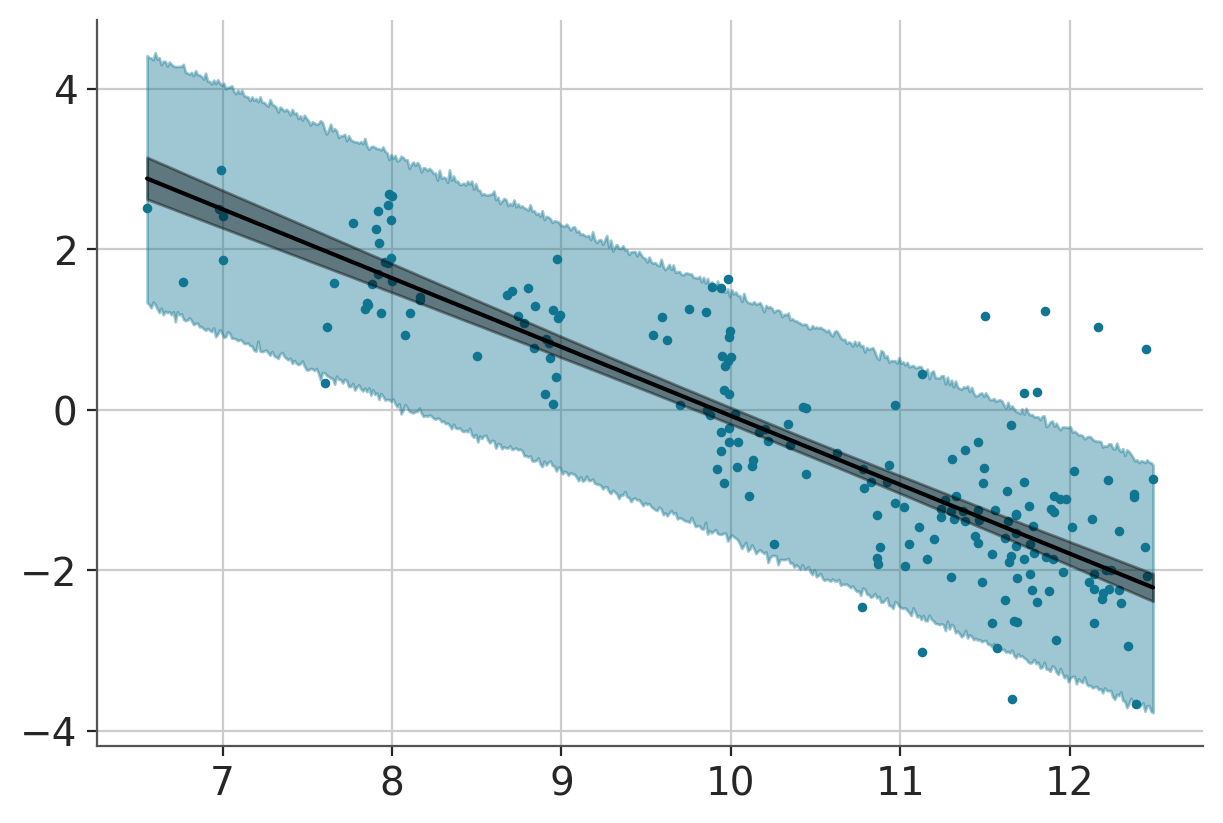

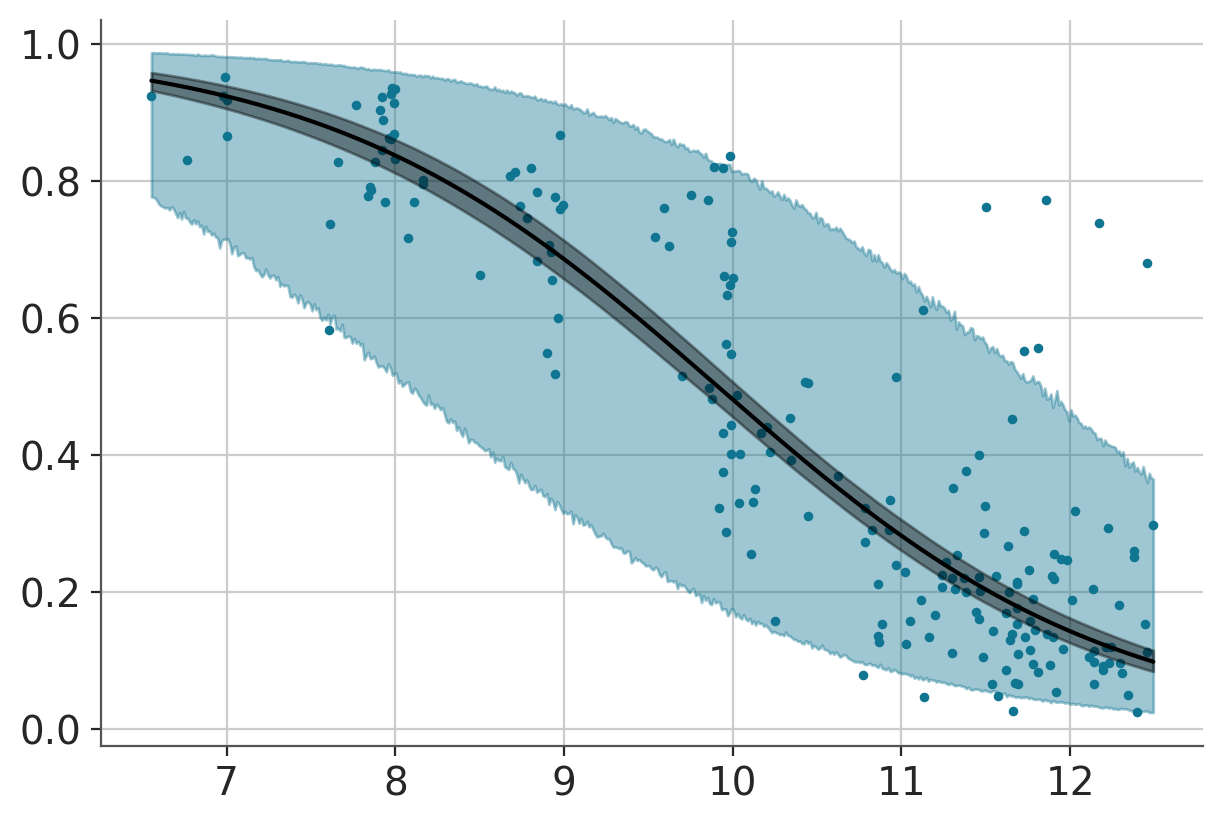

In [45]:
fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

plot_scatter(df_agg, y_transform=logit, s=6)
plot_pps_hdi(model_t, idata_t, color="C0")
plot_model_mean_and_hdi(model_t, idata_t)

fig, ax = plt.subplots(figsize=(6, 4), dpi=200)

plot_scatter(df_agg, s=6, y_transform=identity)
plot_pps_hdi(model, idata, color="C0", y_transform=expit)
plot_model_mean_and_hdi(model_t, idata_t, y_transform=expit)
